# State, Node, Edge로 만드는 단일 LangGraph Chat

LangGraph는 여러 작업이 공유하는 데이터와 실행 순서를 그래프로 표현하는 프레임워크이다.

Chat Model은 LLM을 대화 형식으로 사용하는 인터페이스이다. 사용자의 `HumanMessage`를 받아 모델의 `AIMessage`를 만드는 과정을 LangGraph의 State와 실행 경로로 감싼다.

## 왜 가장 작은 그래프부터 만드는가

Chat Model을 직접 호출하면 입력과 출력만 보인다. LangGraph로 감싸면 **어떤 데이터를 공유하고, 어떤 작업을 거쳐, 어떤 순서로 실행되는지**를 분리해서 볼 수 있다.

### 먼저 구분할 세 요소

- **State**: Node가 함께 읽고 갱신하는 데이터이다. 이 예제에서는 대화를 `messages`에 저장한다.
- **Node**: State를 입력받아 작업하고 State의 변경값을 반환하는 단계이다. `chatbot()` 함수가 Node가 된다.
- **Edge**: 어느 Node 다음에 무엇을 실행할지 정하는 연결선이다.

전체 흐름은 `초기 State → START → chatbot Node → END → 최종 State`이다.


## 실행 환경 준비

세 패키지는 그래프 구성, 모델 연결, 환경 변수 로딩을 각각 담당한다. `%pip`은 현재 Jupyter 커널이 사용하는 Python 환경에 설치한다.

- `langgraph`: State, Node, Edge와 실행 그래프를 만든다.
- `langchain-openai`: OpenAI Chat Model을 `ChatOpenAI` 객체로 연결한다.
- `python-dotenv`: `.env` 파일의 설정을 환경 변수로 불러온다.

In [1]:
%pip install -U langgraph langchain-openai python-dotenv


   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 22.7 MB/s  0:00:00

   ---------------------------------------- 0/6 [truststore]
  Attempting uninstall: python-dotenv
   ---------------------------------------- 0/6 [truststore]
    Found existing installation: python-dotenv 1.2.2
   ---------------------------------------- 0/6 [truststore]
    Uninstalling python-dotenv-1.2.2:
   ---------------------------------------- 0/6 [truststore]
      Successfully uninstalled python-dotenv-1.2.2
   ---------------------------------------- 0/6 [truststore]
   ------ --------------------------------- 1/6 [python-dotenv]
   ------ --------------------------------- 1/6 [python-dotenv]
   ------------- -------------------------- 2/6 [httpcore2]
   ------------- -------------------------- 2/6 [httpcore2]
   ------------- -------------------------- 2/6 [httpcore2]
   ------------- -------------------------- 2/6 [httpcore2]
   


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 모델 인증과 선택적 실행 추적 설정

`.env`는 API key와 모델 ID처럼 코드에 직접 적지 않을 설정을 보관하는 파일이다. 아래 셀은 설정값을 출력하지 않고 필수값의 누락 여부만 검사한다.

### 모델 호출에 사용하는 설정

- `OPENAI_API_KEY`: Chat Model 호출에 필요한 필수 인증값이다.
- `OPENAI_CHAT_MODEL`: 호출할 모델 ID이며, 없으면 수업용 기본값을 사용한다.

### LangSmith 추적에 사용하는 선택 설정

- `LANGSMITH_API_KEY`: 실행 과정을 기록하는 LangSmith의 선택 인증값이다. 없어도 그래프는 실행된다.
- `LANGSMITH_PROJECT`: 여러 trace를 묶는 프로젝트 이름이다.

`setdefault()`는 같은 환경 변수가 이미 있으면 기존 값을 유지한다. 따라서 운영체제나 `.env`에서 정한 LangSmith 설정을 코드가 덮어쓰지 않는다.


In [2]:
import os
from dotenv import find_dotenv, load_dotenv

dotenv_path = find_dotenv(usecwd=True)
load_dotenv(dotenv_path, override=False)

if os.getenv("LANGSMITH_API_KEY"):
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", "langgraph-simple-chat")

OPENAI_CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-5.6-luna")


## 대화 이력을 담는 State schema

**State**는 그래프가 실행되는 동안 실제 값이 담기는 딕셔너리이다. <br>
**State schema**는 그 딕셔너리가 가질 key와 자료형을 미리 정의한다. 아래 `State` schema에는 `messages` key 하나가 있다.

- `TypedDict`: 딕셔너리의 key와 value 자료형을 나타내는 type hint이다. 실행 중 값을 직접 검증하지는 않는다.
- `AnyMessage`: `HumanMessage`, `AIMessage`, `SystemMessage`, `ToolMessage` 등을 함께 표현하는 공통 자료형이다.
- `Annotated[T, 규칙]`: 자료형 `T`에 LangGraph가 사용할 갱신 규칙을 연결한다.

### reducer가 필요한 이유

Node는 전체 State가 아니라 바뀐 값만 **State update**로 반환한다. <br>
같은 key에 기존 값과 새 update가 있을 때 reducer가 둘을 어떻게 합칠지 결정한다.

- reducer가 없으면 새 값이 기존 값을 덮어쓴다.
- `add_messages`를 연결하면 새 message는 뒤에 추가하고, 같은 ID의 message는 교체한다.

이 예제의 갱신 흐름은 `기존 messages + 새 AIMessage → add_messages → 병합된 messages`이다.


In [6]:
from typing import Annotated, TypedDict

from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# 실행 중 'messages' key를 공유하는 dict의 자료형 구조(schema)
class State(TypedDict):
    # list[AnyMessage]: HumanMessage, AIMessage 등을
    #                   시간 순서로 담는 값의 자료형.

    # add_messages: Node가 반환하는 새 Message를
    #               기존 목록에 병합하는 reducer
    messages: Annotated[list[AnyMessage], add_messages]


## Chat Model 호출을 chatbot Node로 만들기

**Node**는 현재 State를 입력받아 작업하고 State update를 반환하는 함수이다.

`chatbot()`은 정의할 때는 일반 Python 함수이고, 뒤에서 `add_node()`로 등록하면 그래프의 Node가 된다.

처리 순서는 다음과 같다.

1. `state["messages"]`에서 지금까지의 대화를 읽는다.
2. `llm.invoke()`가 대화를 OpenAI Chat Model에 전달한다.
3. 반환된 `AIMessage`를 `messages`의 새 update로 돌려준다.


In [7]:
from langchain_openai import ChatOpenAI

# llm 모델 생성
llm = ChatOpenAI(
    model_name=OPENAI_CHAT_MODEL,
    use_responses_api=True
)

# 현재 대화를 읽고 AIMessage Update를 반환하는
# Chatbot Node용 함수를 정의
def chatbot(state:State) -> dict:
    # State에 누적된 대화(list[AnyMessage])를 llm에 입력
    response = llm.invoke(state["messages"])

    # State의 'messages'를 업데이트하기 위한 값을 반환
    # Node 실행 후 add_messages (reducer)가 기존 목록과 병합 수행
    return {"messages": [response]}

### 단일 Node를 연결하고 실행 그래프로 컴파일하기

아래 이미지는 LangGraph의 가장 작은 단일 Node 구조를 나타낸다. <br>
위에서 아래로 `start → node` 순서로 읽는다.

이 실습에서는 `node`의 이름을 `chatbot`으로 지정하고, 종료 위치인 `END`까지 명시적으로 연결한다.

![LangGraph 공식 단일 Node 그래프](https://cdn.jsdelivr.net/gh/goat-skn-ai/image-repo@7f008bd902003af9b0138e956af0be37ffa7a9ff/08_llm/08_langgraph/01_langgraph_basics/02_official_single_node_graph.png)

출처: [LangGraph 공식 Graph API 문서](https://docs.langchain.com/oss/python/langgraph/use-graph-api)

### 설계 객체와 실행 객체

- `StateGraph`: State schema, Node, Edge를 등록하는 **builder**이다. 설계 중인 객체이므로 아직 실행할 수 없다.
- `START`와 `END`: 그래프의 시작과 종료를 표시하는 가상 Node이다.
- `compile()`: 등록된 구조를 검사하고 실행 가능한 `CompiledStateGraph`를 반환한다.

코드는 `START → chatbot → END`를 연결한 후 컴파일한다. 실행하면 `__start__ → chatbot → __end__` 그림으로 실제 구조를 확인할 수 있다.


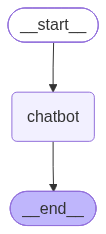

In [8]:
from langgraph.graph import END, START, StateGraph

# 1. StateGraph(State) 생성
# - 모든 Node가 공유하는 State Schema를 입력받아 builder를 만든다
workflow = StateGraph(State)

# 2. add_node(name, action) 노드 등록
# - "chatbot" 이라는 이름의 노드를 등록
# - "chatbot" 노드 호출 시 chatbot 함수를 호출
workflow.add_node("chatbot", chatbot)

# 3. add_edge(source, target) 노드 연결
#- source: 시작 노드
#- target: 도착 노드

# START -> chatbot -> END
workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot", END)

# 4. compile(): 설계 구조를 검사하고, invoke() 가능한 상태로 변경
# - 반환 타입 : CompliedStateGraph
graph = workflow.compile()
display(graph)

## 초기 State를 넣어 그래프 한 번 실행하기

`HumanMessage`는 사용자가 보낸 내용을 나타내는 message 객체이다. 질문 문자열을 `content`에 넣고 초기 State의 `messages` 목록에 담는다.

이 단계에는 이름이 같은 두 `invoke()`가 있지만 호출 대상과 반환값이 다르다.

- `graph.invoke(initial_state)`: 초기 State를 받아 `START`부터 `END`까지 실행하고 **최종 State**를 반환한다.
- `llm.invoke(messages)`: `chatbot` Node 안에서 대화를 모델에 보내고 **AIMessage 하나**를 반환한다.

값은 `HumanMessage → 초기 State → graph.invoke() → chatbot → AIMessage update → add_messages → 최종 State` 순서로 이동한다. `graph.invoke()`가 `chatbot`에 도달할 때 실제 OpenAI API 요청이 발생한다.


In [10]:
from langchain_core.messages import HumanMessage

user_input = "LangGraph가 무엇인지 알려줘. 모르면 모른다고 답해줘."
initial_state = {
    # messages: list[AnyMessage]
    "messages": [HumanMessage(content=user_input)]
}

# final_state는 initial_state의 HumanMessage
#              + LLM의 응답 결과인 AIMessage가 포함되어 있다.
final_state = graph.invoke(initial_state)
# final_state

message_summary = [
    {
        "message_type":type(message).__name__,
        "text":message.text
    }
    for message in final_state["messages"]
]
message_summary

[{'message_type': 'HumanMessage',
  'text': 'LangGraph가 무엇인지 알려줘. 모르면 모른다고 답해줘.'},
 {'message_type': 'AIMessage',
  'text': 'LangGraph는 **LLM 애플리케이션의 작업 흐름을 그래프 구조로 설계하고 실행하기 위한 프레임워크**입니다. LangChain 생태계와 함께 사용되는 경우가 많습니다.\n\n핵심 개념은 다음과 같습니다.\n\n- **노드(Node)**: 실행할 작업  \n  예: LLM 호출, 검색, 도구 실행, 데이터 처리\n- **엣지(Edge)**: 노드 사이의 흐름\n- **상태(State)**: 그래프를 실행하는 동안 공유·갱신되는 데이터\n- **조건부 분기**: 결과에 따라 다음 작업을 다르게 선택\n- **반복 및 순환**: 같은 작업을 여러 번 수행하거나 검토 과정을 반복\n- **체크포인트와 중단/재개**: 실행 상태를 저장하고 나중에 이어서 실행\n- **Human-in-the-loop**: 사람이 중간 결과를 검토하거나 승인하도록 구성\n\n일반적인 LLM 체인은 보통 다음처럼 선형적입니다.\n\n```text\n입력 → LLM → 출력\n```\n\n반면 LangGraph는 다음과 같은 복잡한 흐름을 표현하기 좋습니다.\n\n```text\n질문\n  ↓\n검색\n  ↓\n답변 생성\n  ↓\n검토 ── 부족함 → 추가 검색\n  ↓\n최종 답변\n```\n\n따라서 LangGraph는 다음과 같은 애플리케이션에 적합합니다.\n\n- 여러 에이전트가 협업하는 시스템\n- 검색 후 답변을 검증하는 RAG\n- 도구를 선택적으로 호출하는 AI 에이전트\n- 상태를 유지하는 대화형 애플리케이션\n- 승인 절차가 필요한 자동화 워크플로\n- 실패 시 재시도하거나 이전 단계로 돌아가는 작업\n\n간단히 말하면, **LangGraph는 LLM과 도구 호출을 단순한 일회성 체인이 아니라, 상태를 가진 그래프 기반 워크플로로 만들 수 있게 

## 최종 State에서 답변 텍스트만 선택하기

최종 State의 `messages`는 시간 순서대로 정렬되어 있다. 따라서 `final_state["messages"][-1]`은 `chatbot` Node가 마지막으로 추가한 `AIMessage`이다.

목적에 따라 읽을 범위를 선택한다.

- `.text`: 사용자에게 보여 줄 답변 문자열만 필요할 때 사용한다.
- `.content`: reasoning·text 같은 원본 block을 보존할 때 사용한다.
- AIMessage 전체: 다음 대화나 디버깅에 ID·사용량 metadata까지 필요할 때 사용한다.

아래 셀은 화면에 답변 문장만 보여 주므로 `.text`를 선택한다.


In [11]:
final_ai_message = final_state["messages"][-1]

final_ai_message.text

'LangGraph는 **LLM 애플리케이션의 작업 흐름을 그래프 구조로 설계하고 실행하기 위한 프레임워크**입니다. LangChain 생태계와 함께 사용되는 경우가 많습니다.\n\n핵심 개념은 다음과 같습니다.\n\n- **노드(Node)**: 실행할 작업  \n  예: LLM 호출, 검색, 도구 실행, 데이터 처리\n- **엣지(Edge)**: 노드 사이의 흐름\n- **상태(State)**: 그래프를 실행하는 동안 공유·갱신되는 데이터\n- **조건부 분기**: 결과에 따라 다음 작업을 다르게 선택\n- **반복 및 순환**: 같은 작업을 여러 번 수행하거나 검토 과정을 반복\n- **체크포인트와 중단/재개**: 실행 상태를 저장하고 나중에 이어서 실행\n- **Human-in-the-loop**: 사람이 중간 결과를 검토하거나 승인하도록 구성\n\n일반적인 LLM 체인은 보통 다음처럼 선형적입니다.\n\n```text\n입력 → LLM → 출력\n```\n\n반면 LangGraph는 다음과 같은 복잡한 흐름을 표현하기 좋습니다.\n\n```text\n질문\n  ↓\n검색\n  ↓\n답변 생성\n  ↓\n검토 ── 부족함 → 추가 검색\n  ↓\n최종 답변\n```\n\n따라서 LangGraph는 다음과 같은 애플리케이션에 적합합니다.\n\n- 여러 에이전트가 협업하는 시스템\n- 검색 후 답변을 검증하는 RAG\n- 도구를 선택적으로 호출하는 AI 에이전트\n- 상태를 유지하는 대화형 애플리케이션\n- 승인 절차가 필요한 자동화 워크플로\n- 실패 시 재시도하거나 이전 단계로 돌아가는 작업\n\n간단히 말하면, **LangGraph는 LLM과 도구 호출을 단순한 일회성 체인이 아니라, 상태를 가진 그래프 기반 워크플로로 만들 수 있게 해주는 도구**입니다.'